In [5]:
import numpy as np
import pandas as pd
import nltk
import sklearn

df=pd.read_csv('/content/twitter_centiment_data.csv', on_bad_lines='skip')
df

,Id,Game,Centiment,Tweet
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
...,...,...,...,...
46289,11944,Verizon,Neutral,The last 3 August’s I have broken my phone. Th...
46290,11944,Verizon,Neutral,The last 3 August's I've broken my phone. This...
46291,11944,Verizon,Neutral,The last time I broke my phone was on August 3...
46292,11944,Verizon,Neutral,The last 3 August’s I have broken my phone. Th...


In [6]:
df.shape
df.isnull().sum()

,0
Id,0
Game,0
Centiment,0
Tweet,445


In [7]:
df["Centiment"].value_counts()

,count
Centiment,
Positive,13709
Negative,12300
Neutral,11483
Irrelevant,8802


In [8]:
df=df[["Tweet","Centiment"]]
df

,Tweet,Centiment
0,I am coming to the borders and I will kill you...,Positive
1,im getting on borderlands and i will kill you ...,Positive
2,im coming on borderlands and i will murder you...,Positive
3,im getting on borderlands 2 and i will murder ...,Positive
4,im getting into borderlands and i can murder y...,Positive
...,...,...
46289,The last 3 August’s I have broken my phone. Th...,Neutral
46290,The last 3 August's I've broken my phone. This...,Neutral
46291,The last time I broke my phone was on August 3...,Neutral
46292,The last 3 August’s I have broken my phone. Th...,Neutral


In [9]:
df = df[df["Centiment"] != "Irrelevant"]
df.Centiment.value_counts()
df.dropna()

,Tweet,Centiment
0,I am coming to the borders and I will kill you...,Positive
1,im getting on borderlands and i will kill you ...,Positive
2,im coming on borderlands and i will murder you...,Positive
3,im getting on borderlands 2 and i will murder ...,Positive
4,im getting into borderlands and i can murder y...,Positive
...,...,...
46289,The last 3 August’s I have broken my phone. Th...,Neutral
46290,The last 3 August's I've broken my phone. This...,Neutral
46291,The last time I broke my phone was on August 3...,Neutral
46292,The last 3 August’s I have broken my phone. Th...,Neutral


In [10]:
import nltk
import re

nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
df.isnull().sum

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


<bound method DataFrame.sum of        Tweet  Centiment
0      False      False
1      False      False
2      False      False
3      False      False
4      False      False
...      ...        ...
46289  False      False
46290  False      False
46291  False      False
46292  False      False
46293  False      False

[37492 rows x 2 columns]>

In [11]:
def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stopwords.words('english')]

    words = [ps.stem(word) for word in words]

    return " ".join(words)

In [12]:
df["Cleaned_Tweet"] = df["Tweet"].apply(clean_text)

/tmp/ipykernel_2654/1853841007.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Cleaned_Tweet"] = df["Tweet"].apply(clean_text)


In [13]:
df[["Tweet","Cleaned_Tweet"]].head()

,Tweet,Cleaned_Tweet
0,I am coming to the borders and I will kill you...,come border kill
1,im getting on borderlands and i will kill you ...,im get borderland kill
2,im coming on borderlands and i will murder you...,im come borderland murder
3,im getting on borderlands 2 and i will murder ...,im get borderland murder
4,im getting into borderlands and i can murder y...,im get borderland murder


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["Cleaned_Tweet"])
y = df["Centiment"]

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
print(X_train.shape)
print(X_test.shape)

(29993, 5000)
(7499, 5000)


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["Cleaned_Tweet"])

y = df["Centiment"]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(29993, 5000)
(7499, 5000)


In [24]:
print(X_train.shape)
print(X_test.shape)

(29993, 5000)
(7499, 5000)


In [25]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Accuracy: 0.7886384851313508
              precision    recall  f1-score   support

    Negative       0.79      0.80      0.80      2393
     Neutral       0.79      0.73      0.76      2313
    Positive       0.78      0.82      0.80      2793

    accuracy                           0.79      7499
   macro avg       0.79      0.79      0.79      7499
weighted avg       0.79      0.79      0.79      7499



In [26]:
import pickle

pickle.dump(model, open("sentiment_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully


In [29]:
import pickle

pickle.dump(model, open("sentiment_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

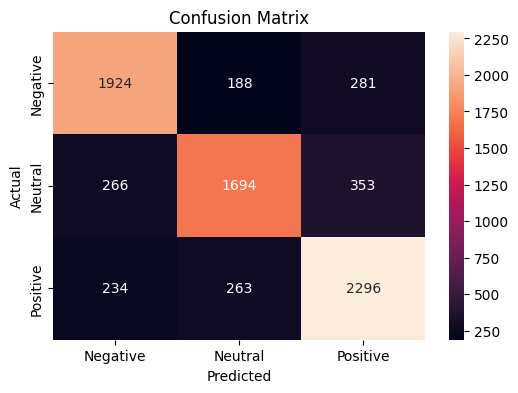

In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()